# PD-YOLO Baseline vs Overlapping Image Tiling

This notebook compares the **same unchanged PD-YOLO checkpoint** in two inference modes. The baseline receives the full image; the tiled mode processes overlapping in-memory 640x640 tiles, translates boxes to original-image coordinates, and applies global class-aware NMS. No architecture, training data, or labels are changed.

In [15]:
from pathlib import Path
import importlib
import time
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import tile_inference
from ultralytics import YOLO

# Reload the local helper so tile geometry changes are picked up in this notebook.
importlib.reload(tile_inference)
from tile_inference import TiledInference, draw_tiles_and_detections, read_image

# Run this notebook from the PD-YOLO repository directory.
WEIGHTS = Path('runs/train/exp12/weights/best.pt')
IMAGE_DIR = Path('dataset/VOC2007/test/images')
IMAGE_PATHS = sorted(IMAGE_DIR.glob('*.jpg'))[:16]
CONFIDENCE = 0.25
NMS_IOU = 0.50
TILE_WIDTH, TILE_HEIGHT, OVERLAP = 640, 640, 0.15
assert WEIGHTS.exists(), f'Missing weights: {WEIGHTS}'
assert len(IMAGE_PATHS) == 16, f'Expected 16 images, found {len(IMAGE_PATHS)} in {IMAGE_DIR}'

In [16]:
# The model is loaded once and reused for all 16 images.
model = YOLO(str(WEIGHTS))
images = [read_image(path) for path in IMAGE_PATHS]
print(f'Loaded {len(images)} images')
print('Image resolution:', images[0].shape[1], 'x', images[0].shape[0])

Loaded 16 images
Image resolution: 720 x 720


In [17]:
# Mode 1 — Original PD-YOLO baseline for all 16 images.
started = time.perf_counter()
baseline_results = model.predict(images, conf=CONFIDENCE, iou=NMS_IOU, verbose=False)
baseline_seconds = time.perf_counter() - started
baseline_views = [result.plot() for result in baseline_results]
baseline_counts = [len(result.boxes) for result in baseline_results]
print(f'Baseline: {sum(baseline_counts)} detections across {len(baseline_results)} images | {baseline_seconds:.3f} s')

Baseline: 18 detections across 16 images | 0.673 s


In [18]:
# Mode 2 — PD-YOLO + tiling for all 16 images, then global NMS per image.
tiled_model = TiledInference(
    model, tile_width=TILE_WIDTH, tile_height=TILE_HEIGHT, overlap_ratio=OVERLAP,
    confidence_threshold=CONFIDENCE, nms_iou_threshold=NMS_IOU
)
started = time.perf_counter()
tiled_results = []
tiles_per_image = []
for image in images:
    detections, tiles = tiled_model.predict(image)
    tiled_results.append(detections)
    tiles_per_image.append(tiles)
tiling_seconds = time.perf_counter() - started
tiled_views = [
    draw_tiles_and_detections(image, tiles, detections, model.names)
    for image, tiles, detections in zip(images, tiles_per_image, tiled_results)
]
tiled_counts = [len(detections) for detections in tiled_results]
print(f'Tiled: {sum(tiled_counts)} detections across {len(tiled_results)} images | {tiling_seconds:.3f} s')

RuntimeError: stride should not be zero

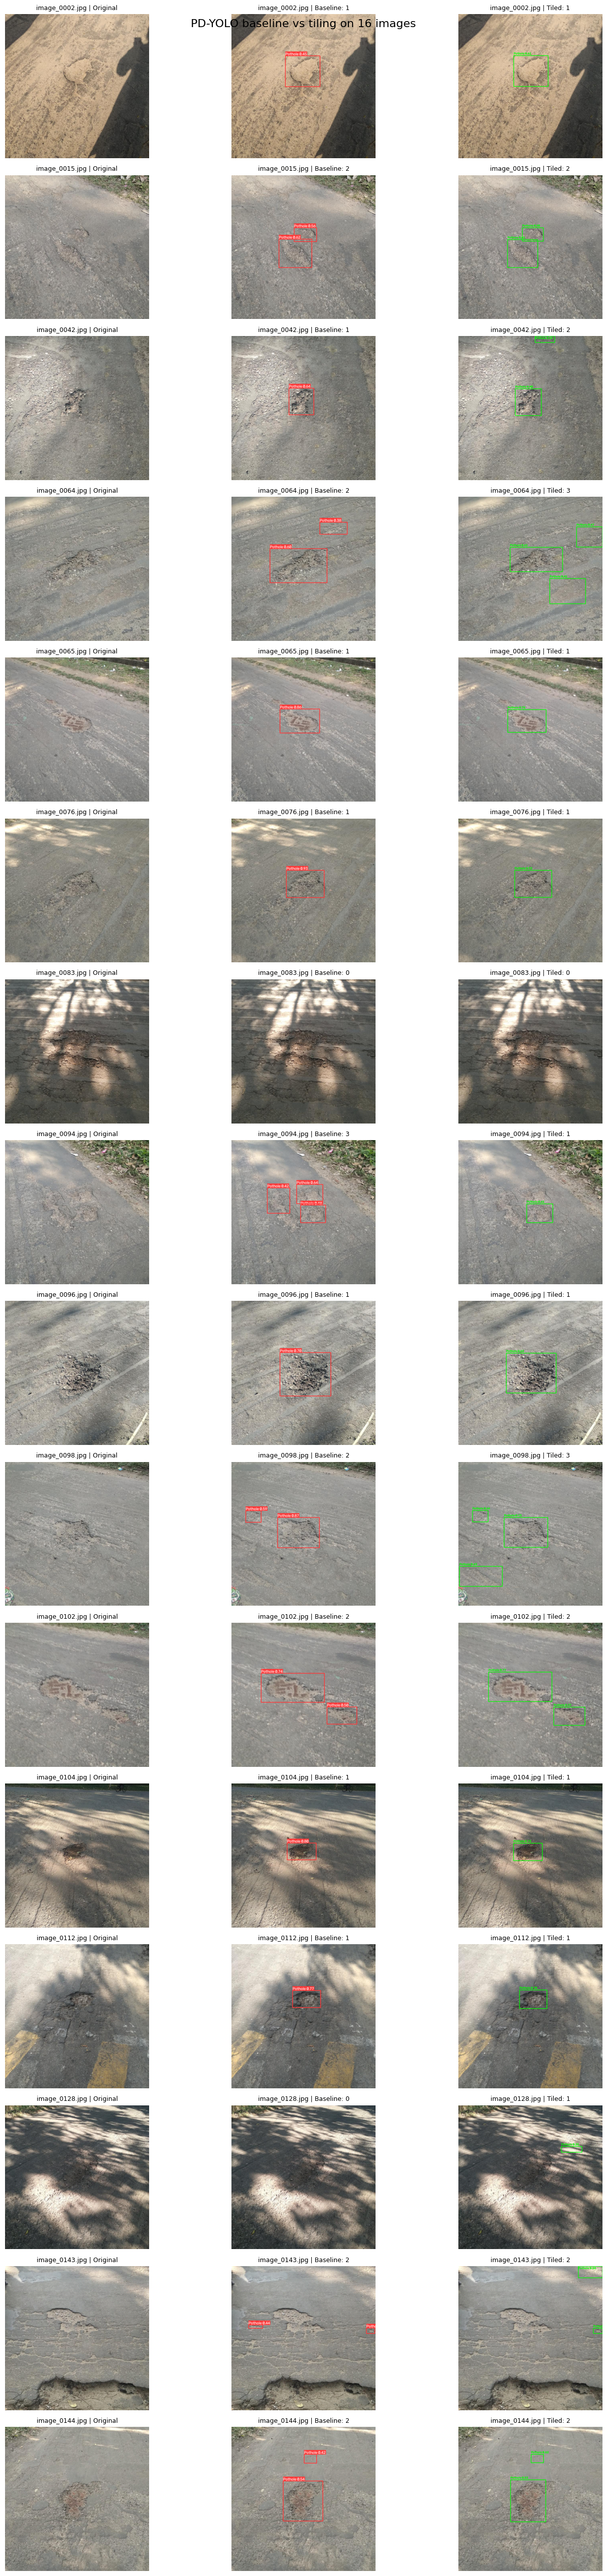

In [ ]:
# Show all 16 comparisons: original, baseline, and tiled result.
fig, axes = plt.subplots(16, 3, figsize=(15, 52))
for row, (image_path, image, baseline_view, tiled_view, baseline_count, tiled_count) in enumerate(
    zip(IMAGE_PATHS, images, baseline_views, tiled_views, baseline_counts, tiled_counts)
):
    views = [
        (image, 'Original'),
        (baseline_view, f'Baseline: {baseline_count}'),
        (tiled_view, f'Tiled: {tiled_count}'),
    ]
    for column, (view, title) in enumerate(views):
        axes[row, column].imshow(cv2.cvtColor(view, cv2.COLOR_BGR2RGB))
        axes[row, column].set_title(f'{image_path.name} | {title}', fontsize=9)
        axes[row, column].axis('off')
fig.suptitle('PD-YOLO baseline vs tiling on 16 images', fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.995))
plt.show()

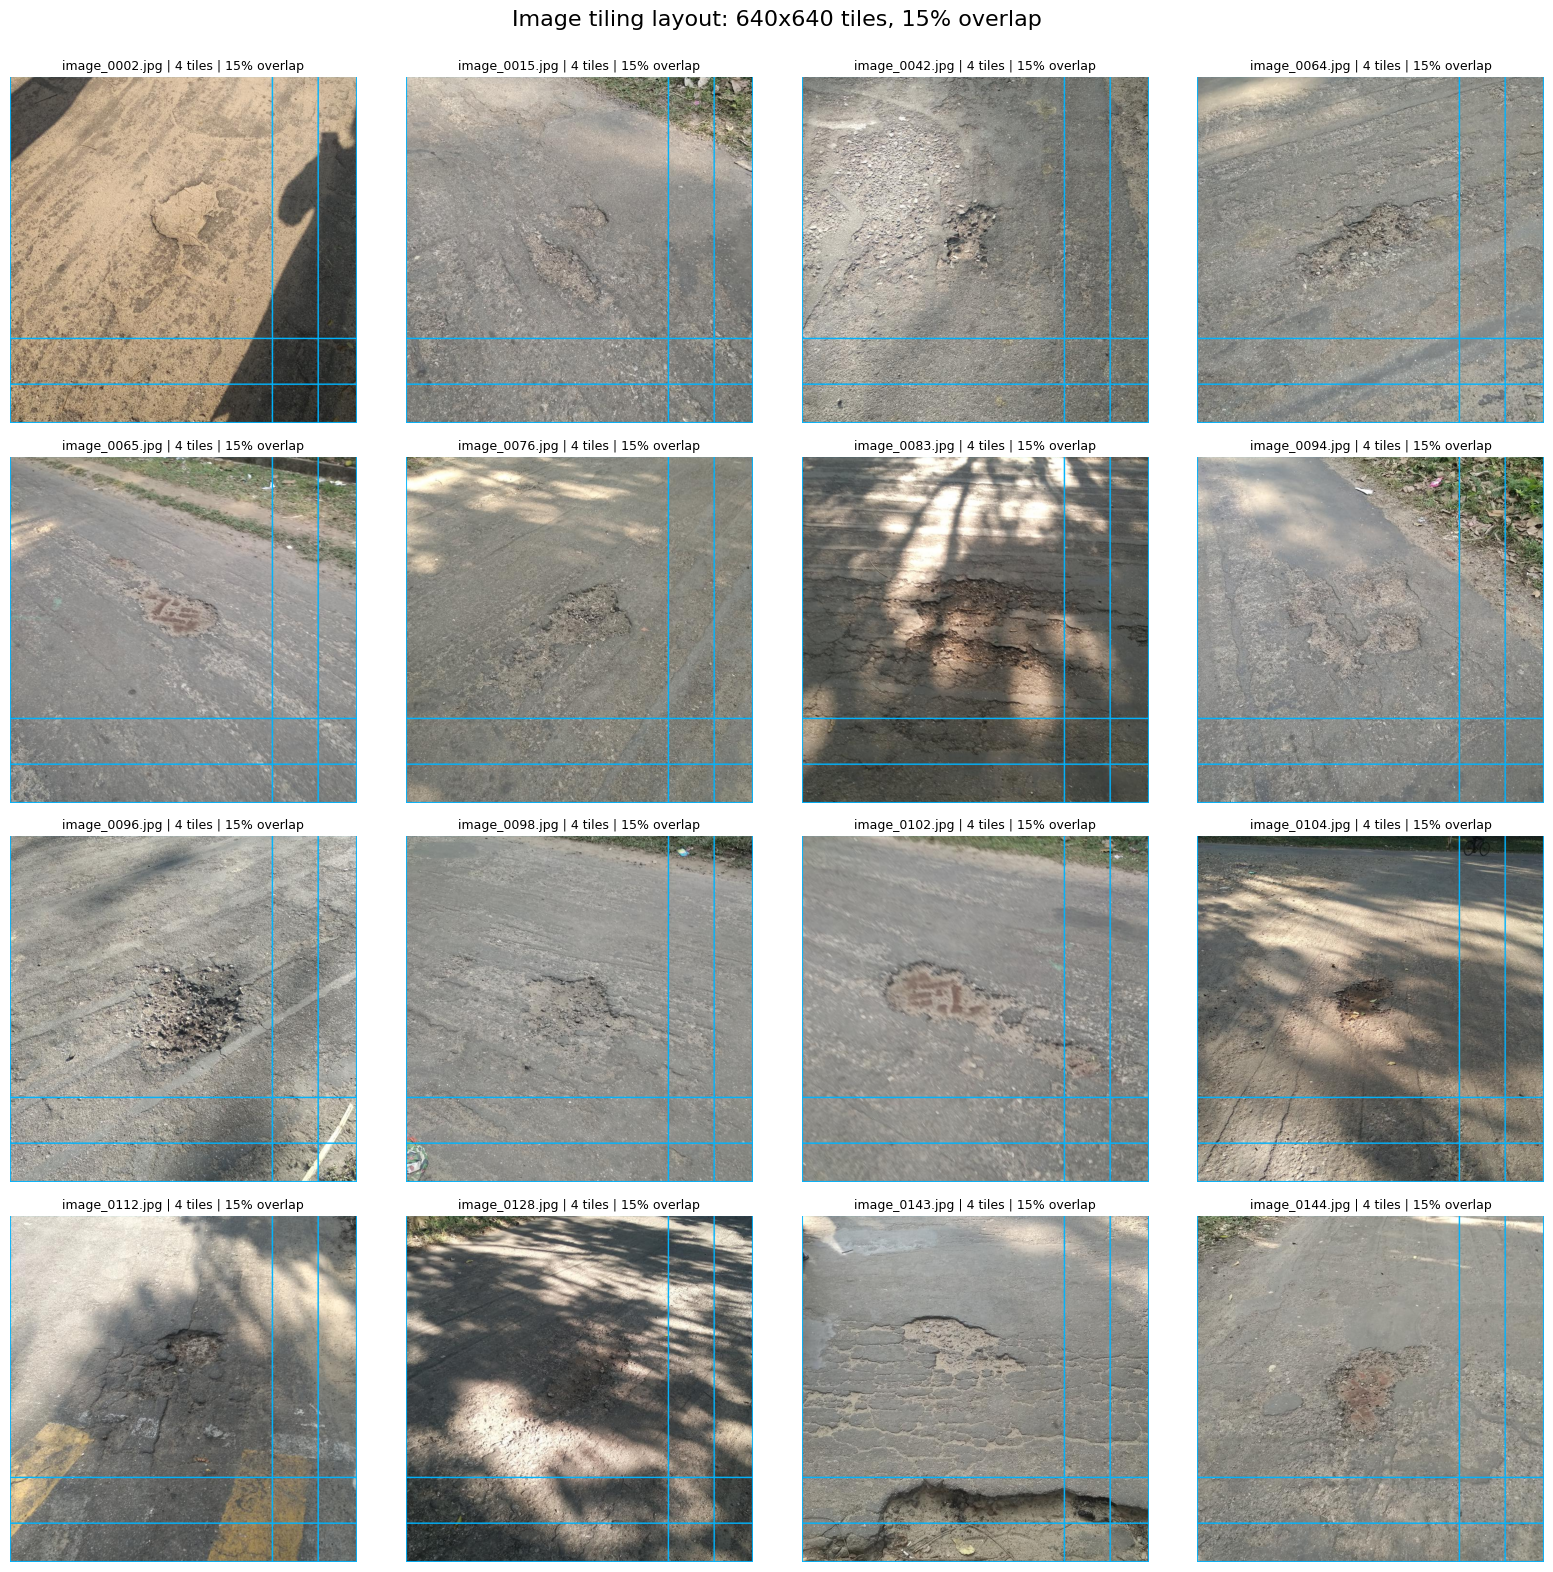

Saved 16-image comparison: runs\demo\baseline_vs_tiling_16_images.jpg
Saved tiling layout: runs\demo\tiling_layout_16_images.jpg
Saved CSV summary: runs\demo\baseline_vs_tiling_16_images.csv


,image,tiles,baseline_detections,tiled_detections,difference
0,image_0002.jpg,4,1,1,0
1,image_0015.jpg,4,2,2,0
2,image_0042.jpg,4,1,2,1
3,image_0064.jpg,4,2,3,1
4,image_0065.jpg,4,1,1,0
5,image_0076.jpg,4,1,1,0
6,image_0083.jpg,4,0,0,0
7,image_0094.jpg,4,3,1,-2
8,image_0096.jpg,4,1,1,0
9,image_0098.jpg,4,2,3,1


In [ ]:
# Save the complete 16-image comparison, tile layout, and CSV summary.
comparison_output = Path('runs/demo/baseline_vs_tiling_16_images.jpg')
comparison_output.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(comparison_output, dpi=120, bbox_inches='tight')

tile_layout_views = [
    draw_tiles_and_detections(image, tiles, [], model.names, draw_tiles=True)
    for image, tiles in zip(images, tiles_per_image)
]
tile_fig, tile_axes = plt.subplots(4, 4, figsize=(16, 16))
for axis, image_path, tile_view, tiles in zip(tile_axes.flat, IMAGE_PATHS, tile_layout_views, tiles_per_image):
    axis.imshow(cv2.cvtColor(tile_view, cv2.COLOR_BGR2RGB))
    axis.set_title(f'{image_path.name} | {len(tiles)} tiles | {OVERLAP:.0%} overlap', fontsize=9)
    axis.axis('off')
tile_fig.suptitle(
    f'Image tiling layout: {TILE_WIDTH}x{TILE_HEIGHT} tiles, {OVERLAP:.0%} overlap',
    fontsize=16,
)
tile_fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

tile_output = Path('runs/demo/tiling_layout_16_images.jpg')
tile_fig.savefig(tile_output, dpi=120, bbox_inches='tight')

summary = pd.DataFrame({
    'image': [path.name for path in IMAGE_PATHS],
    'tiles': [len(tiles) for tiles in tiles_per_image],
    'baseline_detections': baseline_counts,
    'tiled_detections': tiled_counts,
    'difference': [tiled - baseline for tiled, baseline in zip(tiled_counts, baseline_counts)],
})
summary_output = Path('runs/demo/baseline_vs_tiling_16_images.csv')
summary.to_csv(summary_output, index=False)
print(f'Saved 16-image comparison: {comparison_output}')
print(f'Saved tiling layout: {tile_output}')
print(f'Saved CSV summary: {summary_output}')
summary

## Interpretation

This is a visual/speed demo for one image, not a performance claim. Use `evaluate_tiling.py` on the same test split for precision, recall, mAP50, and mAP50-95; compare those JSON files before concluding that tiling improves small-pothole detection.